##### Name: Oghenetega Clinton Okotie
##### Student ID: E4611415
##### Course Code: CIS4035-N
##### Project Title: Design and Evaluation of a Machine Learning-Based System for Predicting and Analysing Rental Property Prices in the UK Housing Market


### Step 1: Import Libraries


In [5]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing and model selection
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import xgboost as xgb

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Save/load model
import joblib

# For consistent results
np.random.seed(42)

### Step 2: Load the dataset

In [6]:
# Read the rental housing dataset
df = pd.read_csv("uk_housing_rentals.csv")

# Display the first 5 rows to understand the data
df.head()

,Unnamed: 0,Description,Location,Number of Rooms,Price
0,0,1 Bedroom Flat For Rent,"Birmingham, West Midla...",1 bedroom,£ 625 ...
1,1,1 Bedroom Flat For Rent,"Birmingham, West Midla...",1 bedroom,£ 625 ...
2,2,"4B Paddington Basin, London, W2","London, Greater London...",3 bedrooms,"£ 6,000 ..."
3,3,2 Bedroom Terraced House to Rent in Albert Roa...,"London, Greater London...",2 bedrooms,"£ 1,400 ..."
4,4,2 Bedroom Terraced House to Rent in Albert Roa...,"London, Greater London...",2 bedrooms,"£ 1,400 ..."


### Step 3: Data Exploration

In this step, the structure of the dataset is explored to understand the
available features, dataset size, and statistical properties. This helps
identify potential issues such as incorrect data types or missing values
before performing data preprocessing.

In [7]:
print("=== Data Exploration: UK Rental Properties Dataset ===\n")

# Display column names
print("Columns in the dataset:")
for col in df.columns:
    print("-", col)

# Display the first 5 rows of the dataset
print("\nFirst 5 rows of the dataset:")
display(df.head())

# Display the number of rows and columns
print("\nShape of dataset:", df.shape)

# Display dataset information including data types and missing values
print("\nDataset Info:")
df.info()

# Display basic statistical summary of numeric columns
print("\nBasic Statistical Summary:")
display(df.describe())

# Preview the raw values of the Price column
print("\nPreview of Price column (raw values):")
display(df['Price'].head(10))

=== Data Exploration: UK Rental Properties Dataset ===

Columns in the dataset:
- Unnamed: 0
- Description
- Location
- Number of Rooms
- Price

First 5 rows of the dataset:


,Unnamed: 0,Description,Location,Number of Rooms,Price
0,0,1 Bedroom Flat For Rent,"Birmingham, West Midla...",1 bedroom,£ 625 ...
1,1,1 Bedroom Flat For Rent,"Birmingham, West Midla...",1 bedroom,£ 625 ...
2,2,"4B Paddington Basin, London, W2","London, Greater London...",3 bedrooms,"£ 6,000 ..."
3,3,2 Bedroom Terraced House to Rent in Albert Roa...,"London, Greater London...",2 bedrooms,"£ 1,400 ..."
4,4,2 Bedroom Terraced House to Rent in Albert Roa...,"London, Greater London...",2 bedrooms,"£ 1,400 ..."



Shape of dataset: (39039, 5)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39039 entries, 0 to 39038
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Unnamed: 0       39039 non-null  int64 
 1   Description      39039 non-null  object
 2   Location         39039 non-null  object
 3   Number of Rooms  39039 non-null  object
 4   Price            39039 non-null  object
dtypes: int64(1), object(4)
memory usage: 1.5+ MB

Basic Statistical Summary:


,Unnamed: 0
count,39039.000000
mean,14056.481826
std,10376.635315
min,0.000000
25%,3654.500000
50%,13414.000000
75%,23173.500000
max,32933.000000



Preview of Price column (raw values):


0                                £ 625             ...
1                                £ 625             ...
2                                £ 6,000           ...
3                                £ 1,400           ...
4                                £ 1,400           ...
5                                £ 2,817           ...
6                                £ 1,525           ...
7                                £ 346             ...
8                                £ 2,058           ...
9                                £ 2,000           ...
Name: Price, dtype: object

## Step 4: Data Preprocessing

### 4.1 Checking the Dataset Before Preprocessing

Before cleaning the dataset, it is important to inspect the current structure
and data types. This helps confirm which columns need preprocessing.

In [8]:
# Display the shape of the dataset before preprocessing
print("Dataset shape before preprocessing:", df.shape)

# Display the data types of each column
print("\nCurrent data types:")
display(df.dtypes)

# Preview the first 5 rows
print("\nPreview of dataset before preprocessing:")
display(df.head())

Dataset shape before preprocessing: (39039, 5)

Current data types:


Unnamed: 0          int64
Description        object
Location           object
Number of Rooms    object
Price              object
dtype: object


Preview of dataset before preprocessing:


,Unnamed: 0,Description,Location,Number of Rooms,Price
0,0,1 Bedroom Flat For Rent,"Birmingham, West Midla...",1 bedroom,£ 625 ...
1,1,1 Bedroom Flat For Rent,"Birmingham, West Midla...",1 bedroom,£ 625 ...
2,2,"4B Paddington Basin, London, W2","London, Greater London...",3 bedrooms,"£ 6,000 ..."
3,3,2 Bedroom Terraced House to Rent in Albert Roa...,"London, Greater London...",2 bedrooms,"£ 1,400 ..."
4,4,2 Bedroom Terraced House to Rent in Albert Roa...,"London, Greater London...",2 bedrooms,"£ 1,400 ..."


### 4.2 Cleaning the Price Column

The price column contains currency symbols (£), commas, and extra text.
These must be removed so that the values can be converted into numeric
format for machine learning analysis.

In [9]:
# Convert Price column to string
df['Price'] = df['Price'].astype(str)

# Remove the £ symbol
df['Price'] = df['Price'].str.replace('£', '', regex=False)

# Remove commas
df['Price'] = df['Price'].str.replace(',', '', regex=False)

# Extract only the numeric part of the price
df['Price'] = df['Price'].str.extract(r'(\d+)')

# Convert Price to float
df['Price'] = df['Price'].astype(float)

# Preview the cleaned Price column
display(df['Price'].head())

print("Dataset shape:", df.shape)

0     625.0
1     625.0
2    6000.0
3    1400.0
4    1400.0
Name: Price, dtype: float64

Dataset shape: (39039, 5)


### 4.3 Cleaning the Number of Rooms Column

The "Number of Rooms" column contains values such as "1 bedroom" and
"2 bedrooms", but also includes invalid entries such as "Not Specified"
and square footage values. Only rows containing valid bedroom information
are kept, and the numeric bedroom values are extracted.

In [10]:
# Convert Number of Rooms to string
df['Number of Rooms'] = df['Number of Rooms'].astype(str)

# Keep only rows that contain the word "bedroom"
df = df[df['Number of Rooms'].str.contains('bedroom', case=False, na=False)]

# Extract the numeric part from values like "1 bedroom" or "2 bedrooms"
df['Number of Rooms'] = df['Number of Rooms'].str.extract(r'(\d+)')

# Convert Number of Rooms to integer
df['Number of Rooms'] = df['Number of Rooms'].astype(int)

# Preview the cleaned Number of Rooms column
display(df['Number of Rooms'].head())

print("Dataset shape:", df.shape)

0    1
1    1
2    3
3    2
4    2
Name: Number of Rooms, dtype: int64

Dataset shape: (38952, 5)


### 4.4 Removing Unnecessary Columns

The column "Unnamed: 0" is an index column and does not provide useful
information for prediction. Therefore, it is removed from the dataset.

In [11]:
# Remove the unnecessary index column if it exists
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

# Display remaining columns
print("Remaining columns:")
display(df.columns)

print("Dataset shape:", df.shape)


Remaining columns:


Index(['Description', 'Location', 'Number of Rooms', 'Price'], dtype='object')

Dataset shape: (38952, 4)


### 4.5 Identifying and Removing Duplicate Records

Duplicate records may occur in datasets that are collected through web
scraping or repeated property listings. Identifying duplicate entries is
important to ensure that the machine learning model is trained on unique
observations.

In this step, the number of duplicate rows in the dataset is first
identified. The duplicate records are then removed to retain only unique
property listings for analysis and modelling.

In [12]:
# Check dataset shape before removing duplicates
print("Dataset shape before removing duplicates:", df.shape)

# Count duplicate rows
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows in the dataset:", duplicate_count)

# Remove duplicate rows
df = df.drop_duplicates()

# Check dataset shape after removing duplicates
print("Dataset shape after removing duplicates:", df.shape)

# Save cleaned dataset
df.to_csv("cleaned_uk_housing_rentals.csv", index=False)

print("Cleaned dataset saved successfully.")

Dataset shape before removing duplicates: (38952, 4)
Number of duplicate rows in the dataset: 36959
Dataset shape after removing duplicates: (1993, 4)
Cleaned dataset saved successfully.


### 4.6 Checking for Missing Values

The dataset is checked for missing values to ensure that the remaining
features are complete and suitable for further analysis and modelling.

In [13]:
# Check missing values in each column
missing_values = df.isnull().sum()

print("Missing values in each column:")
display(missing_values)


Missing values in each column:


Description        0
Location           0
Number of Rooms    0
Price              0
dtype: int64

### 4.7 Preview of the Cleaned Dataset

After preprocessing, the cleaned dataset is previewed to confirm that
the cleaning steps were successful. The final structure, size, and data
types are checked before proceeding to exploratory data analysis.

In [14]:
# Display the first 5 rows of the cleaned dataset
print("Preview of cleaned dataset:")
display(df.head())

# Display the final shape of the dataset
print("Final dataset shape after preprocessing:", df.shape)

# Display updated dataset information
print("\nUpdated dataset information:")
df.info()

Preview of cleaned dataset:


,Description,Location,Number of Rooms,Price
0,1 Bedroom Flat For Rent,"Birmingham, West Midla...",1,625.0
2,"4B Paddington Basin, London, W2","London, Greater London...",3,6000.0
3,2 Bedroom Terraced House to Rent in Albert Roa...,"London, Greater London...",2,1400.0
5,"1 Bedroom Apartment to Rent in Hill Street, Ma...","London, Greater London...",1,2817.0
6,"2 Bedroom Flat to Rent in Greystoke Court, Eal...","London, Greater London...",2,1525.0


Final dataset shape after preprocessing: (1993, 4)

Updated dataset information:
<class 'pandas.core.frame.DataFrame'>
Index: 1993 entries, 0 to 39037
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Description      1993 non-null   object 
 1   Location         1993 non-null   object 
 2   Number of Rooms  1993 non-null   int64  
 3   Price            1993 non-null   float64
dtypes: float64(1), int64(1), object(2)
memory usage: 77.9+ KB


### 4.8 Log Transformation of Rental Prices

Rental price data is often highly skewed due to the presence of luxury
properties with extremely high rental values. To reduce skewness and
improve model performance, a logarithmic transformation is applied to
the price column.

This transformation helps stabilise variance and improves the ability
of machine learning models to learn patterns in the data.

In [15]:
# Create log-transformed price
df['Log_Price'] = np.log(df['Price'])

# Check the new column
display(df[['Price','Log_Price']].head())

,Price,Log_Price
0,625.0,6.437752
2,6000.0,8.699515
3,1400.0,7.244228
5,2817.0,7.943428
6,1525.0,7.329750


## Step 5: Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand the structure,
distribution, and relationships within the dataset. This step helps identify
patterns in rental prices and key factors influencing property rental values
across the UK housing market.

The analysis includes examining the distribution of rental prices,
distribution of the number of rooms, relationships between rooms and rental
prices, and identifying the most expensive rental locations.

### 5.1 Distribution of Rental Prices

This visualization shows how rental prices are distributed across the dataset.
Understanding the distribution of rental prices helps identify common price
ranges and detect potential outliers in the UK rental housing market.

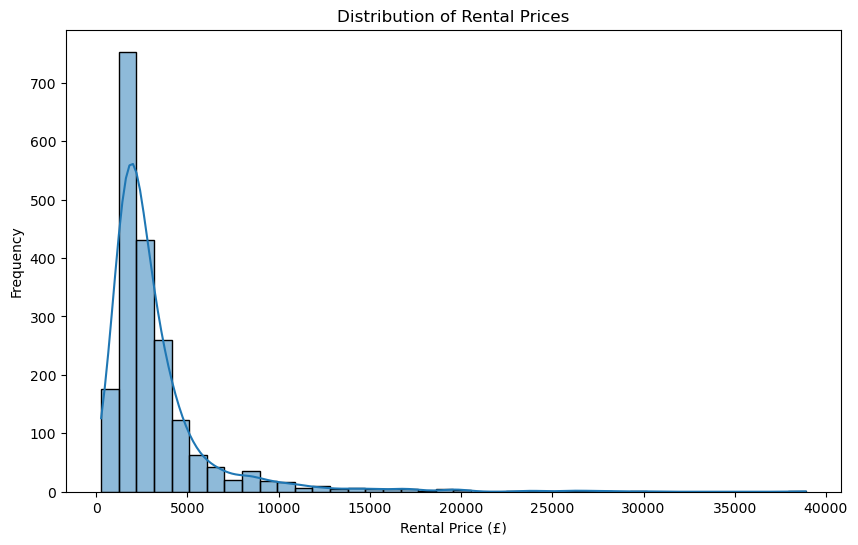

In [16]:
plt.figure(figsize=(10,6))

sns.histplot(df['Price'], bins=40, kde=True)

plt.title("Distribution of Rental Prices")
plt.xlabel("Rental Price (£)")
plt.ylabel("Frequency")

plt.show()

### 5.2 Distribution of Number of Rooms

This analysis examines how many rooms are typically available in rental
properties within the dataset. Understanding this distribution helps
identify the most common property sizes in the UK rental market.

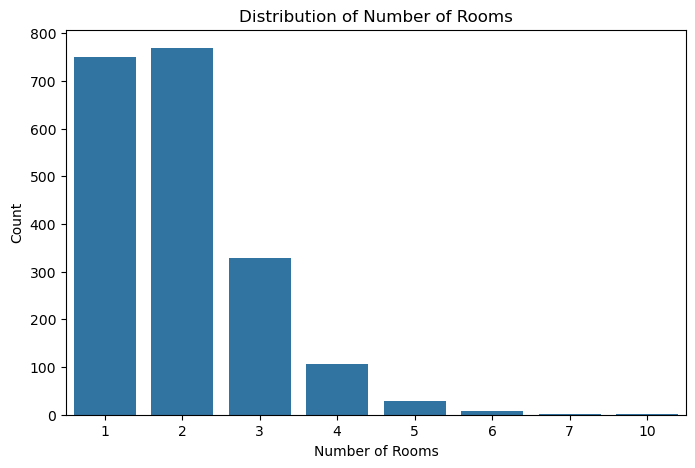

In [17]:
plt.figure(figsize=(8,5))

sns.countplot(x='Number of Rooms', data=df)

plt.title("Distribution of Number of Rooms")
plt.xlabel("Number of Rooms")
plt.ylabel("Count")

plt.show()

### 5.3 Relationship Between Number of Rooms and Rental Price

This visualization explores the relationship between the number of rooms
in a property and its rental price. It helps determine whether properties
with more rooms tend to have higher rental prices.

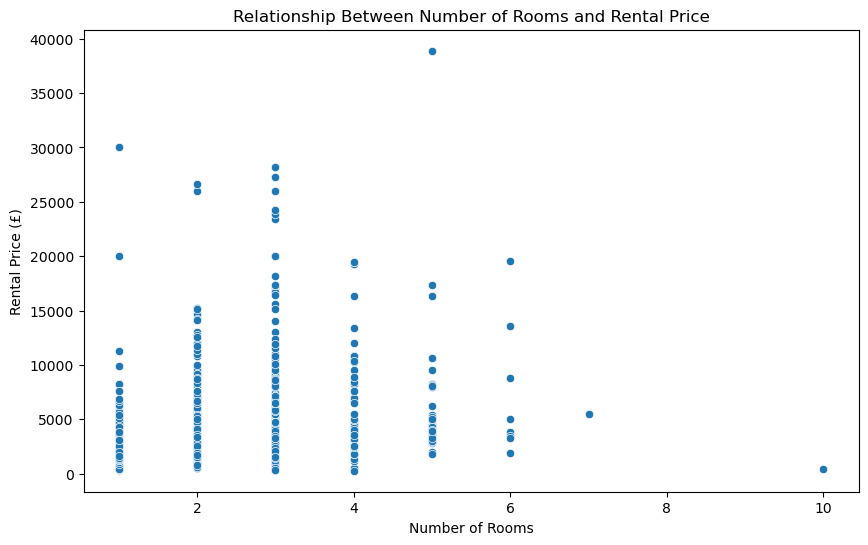

In [18]:
plt.figure(figsize=(10,6))

sns.scatterplot(x='Number of Rooms', y='Price', data=df)

plt.title("Relationship Between Number of Rooms and Rental Price")
plt.xlabel("Number of Rooms")
plt.ylabel("Rental Price (£)")

plt.show()

### 5.4 Average Rental Price by Location

Rental prices often vary significantly depending on location. This analysis
calculates the average rental price for each location and identifies the
most expensive areas within the dataset.

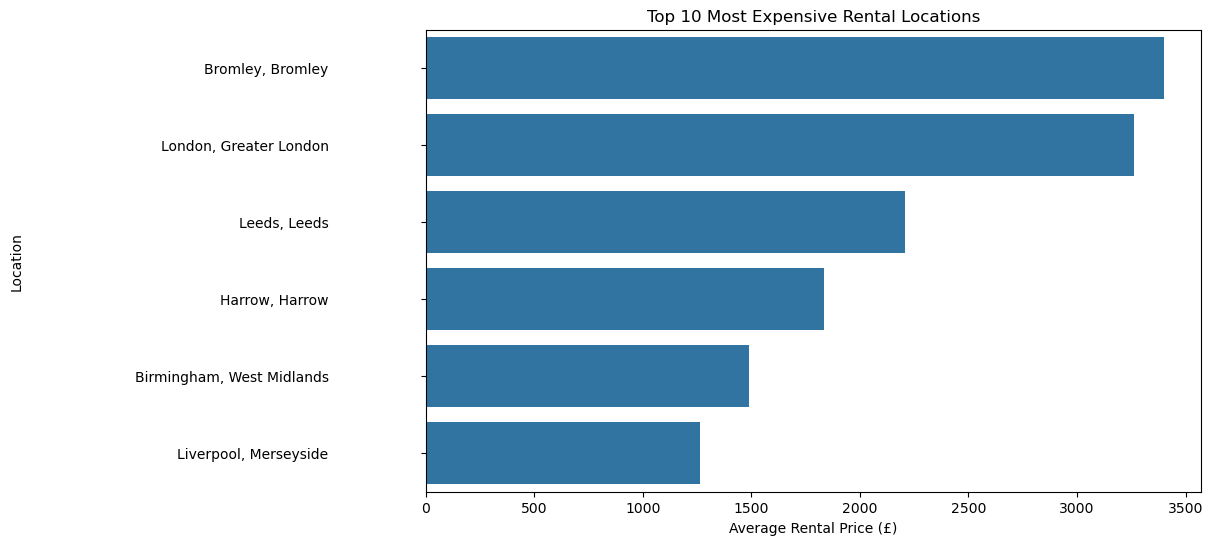

In [19]:
# Calculate average price by location
location_price = df.groupby('Location')['Price'].mean().sort_values(ascending=False)

# Select top 10 most expensive locations
top_locations = location_price.head(10)

plt.figure(figsize=(10,6))

sns.barplot(x=top_locations.values, y=top_locations.index)

plt.title("Top 10 Most Expensive Rental Locations")
plt.xlabel("Average Rental Price (£)")
plt.ylabel("Location")

plt.show()

### 5.5 Detecting Outliers in Rental Prices

Outliers can significantly affect machine learning models and statistical
analysis. A boxplot is used to visualise the distribution of rental prices
and identify extreme values that may represent unusually high or low
property listings within the dataset.

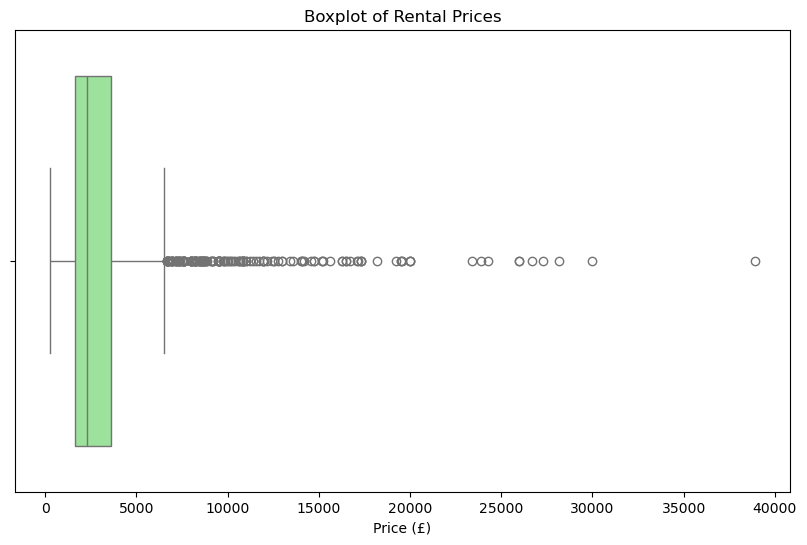

In [20]:
# Boxplot of rental prices to check for outliers

plt.figure(figsize=(10,6))

sns.boxplot(x=df['Price'], color='lightgreen')

plt.title("Boxplot of Rental Prices")
plt.xlabel("Price (£)")

plt.show()

### 5.6 Correlation Analysis

Correlation analysis helps identify relationships between numerical features
in the dataset. In this case, a heatmap is used to visualise the correlation
between rental price and the number of rooms. Understanding this relationship
is important because properties with more rooms are generally expected to
have higher rental prices.

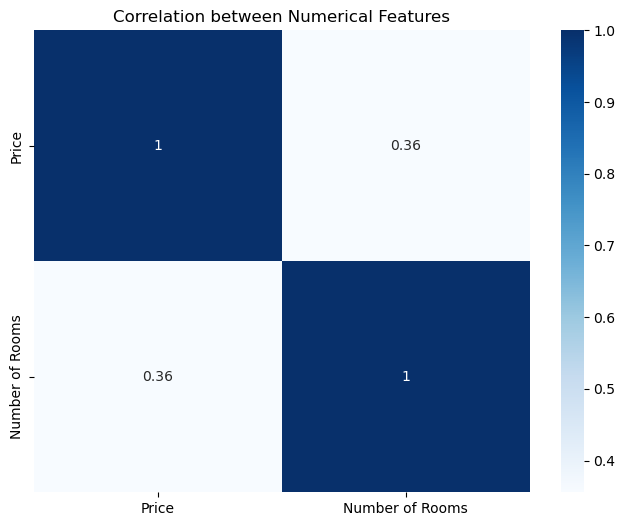

In [21]:
# Correlation heatmap for numerical features

plt.figure(figsize=(8,6))

sns.heatmap(df[['Price','Number of Rooms']].corr(),
            annot=True,
            cmap='Blues')

plt.title("Correlation between Numerical Features")

plt.show()

### 5.7 Skewness Analysis of Rental Prices

Skewness analysis is performed to understand the distribution of rental
prices in the dataset. A highly skewed distribution may indicate the
presence of extreme values or luxury properties that significantly
increase rental prices.

Calculating skewness helps determine whether transformations such as
log scaling may be useful before training machine learning models.

Skewness of Price: 4.12415494877627


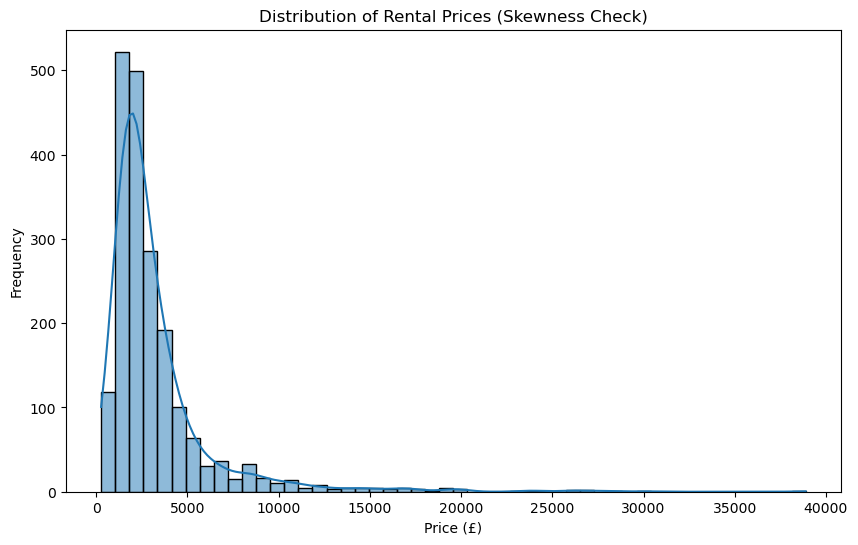

In [22]:
# Calculate skewness of the Price column
skewness = df['Price'].skew()

print("Skewness of Price:", skewness)

# Visualise the distribution of rental prices
plt.figure(figsize=(10,6))

sns.histplot(df['Price'], bins=50, kde=True)

plt.title("Distribution of Rental Prices (Skewness Check)")
plt.xlabel("Price (£)")
plt.ylabel("Frequency")

plt.show()

## Step 6: Feature Engineering

Feature engineering is performed to transform the cleaned dataset into a
format suitable for machine learning models. In this step, a new city
feature is extracted from the location column, the target variable is
defined, relevant input features are selected, categorical values are
encoded into numerical format, and feature scaling is applied where
necessary.

### 6.1 Extracting City from Location

The location column contains detailed address information such as city,
region, and postcode. For machine learning and analysis purposes, the
city name is extracted from the location field to create a clearer and
more meaningful geographic feature.

In [23]:
# Extract the city name from the Location column
df['City'] = df['Location'].str.split(',').str[0].str.strip()

# Preview the original Location column and the new City column
display(df[['Location', 'City']].head())

,Location,City
0,"Birmingham, West Midla...",Birmingham
2,"London, Greater London...",London
3,"London, Greater London...",London
5,"London, Greater London...",London
6,"London, Greater London...",London


### 6.2 Extracting Property Type from Description

The property description often includes information about the type of property such as flat, apartment, house, or studio.  
Property type can influence rental prices because different types of housing provide varying levels of space and amenities.

To capture this information, the description text is analysed and a new feature called **Property_Type** is created.  
This feature categorises each listing into common housing types such as Flat, Apartment, House, or Studio.

In [24]:
df['Property_Type'] = 'Other'

df.loc[df['Description'].str.contains('flat', case=False), 'Property_Type'] = 'Flat'
df.loc[df['Description'].str.contains('apartment', case=False), 'Property_Type'] = 'Apartment'
df.loc[df['Description'].str.contains('house', case=False), 'Property_Type'] = 'House'
df.loc[df['Description'].str.contains('studio', case=False), 'Property_Type'] = 'Studio'

display(df[['Description','Property_Type']].head())

,Description,Property_Type
0,1 Bedroom Flat For Rent,Flat
2,"4B Paddington Basin, London, W2",Other
3,2 Bedroom Terraced House to Rent in Albert Roa...,House
5,"1 Bedroom Apartment to Rent in Hill Street, Ma...",Apartment
6,"2 Bedroom Flat to Rent in Greystoke Court, Eal...",Flat


### 6.3 Defining the Target Variable

The target variable is the value that the machine learning models will
predict. In this project, the target variable is the rental price of
the property.

In [25]:
# Define the target variable
y = df['Log_Price']

# Preview the target variable
display(y.head())

0    6.437752
2    8.699515
3    7.244228
5    7.943428
6    7.329750
Name: Log_Price, dtype: float64

### 6.4 Selecting Input Features
After completing feature engineering, the next step is to define the input variables that will be used by the machine learning models.

The selected features include:
- **City** – representing the location of the property
- **Number of Rooms** – representing the size of the property
- **Property_Type** – representing the type of housing (e.g., flat, apartment, house, studio)

These features were selected because they are key factors that influence rental prices in the housing market.

In [26]:
# Select the input features
X = df[['City', 'Number of Rooms', 'Property_Type']]

# Preview the selected features
display(X.head())

,City,Number of Rooms,Property_Type
0,Birmingham,1,Flat
2,London,3,Other
3,London,2,House
5,London,1,Apartment
6,London,2,Flat


### 6.5 Encoding Categorical Variables

Machine learning algorithms require numerical input features.  
However, the dataset contains categorical variables such as **City** and **Property_Type**.

To convert these categorical variables into numerical format, **One-Hot Encoding** is applied.  
This technique creates binary indicator variables for each category.

The parameter **drop_first=True** is used to prevent multicollinearity by removing one redundant category from each encoded feature.

In [27]:
# Apply one-hot encoding to categorical features
X_encoded = pd.get_dummies(X, columns=['City', 'Property_Type'], drop_first=True)

# Preview the encoded feature dataset
display(X_encoded.head())

,Number of Rooms,City_Bromley,City_Harrow,City_Leeds,City_Liverpool,City_London,Property_Type_Flat,Property_Type_House,Property_Type_Other,Property_Type_Studio
0,1,False,False,False,False,False,True,False,False,False
2,3,False,False,False,False,True,False,False,True,False
3,2,False,False,False,False,True,False,True,False,False
5,1,False,False,False,False,True,False,False,False,False
6,2,False,False,False,False,True,True,False,False,False


### 6.5 Applying Feature Scaling

Machine learning algorithms often perform better when numerical features are on a similar scale.  
Feature scaling ensures that variables with larger ranges do not dominate those with smaller ranges.

In this project, **StandardScaler** is used to standardize the features by transforming them to have a mean of 0 and a standard deviation of 1.

Although tree-based models such as Random Forest and Gradient Boosting do not require scaling, it is applied here to support models such as **Linear Regression**, which are sensitive to feature magnitude.

In [28]:
# Create a scaler object
scaler = StandardScaler()

# Scale the encoded feature dataset
X_scaled = scaler.fit_transform(X_encoded)

# Convert the scaled data back to a dataframe
X_scaled = pd.DataFrame(X_scaled, columns=X_encoded.columns, index=X_encoded.index)

# Preview the scaled feature dataset
display(X_scaled.head())

,Number of Rooms,City_Bromley,City_Harrow,City_Leeds,City_Liverpool,City_London,Property_Type_Flat,Property_Type_House,Property_Type_Other,Property_Type_Studio
0,-0.964997,-0.022406,-0.044845,-0.022406,-0.031694,-12.341300,1.672181,-0.437348,-0.510485,-0.209767
2,1.042559,-0.022406,-0.044845,-0.022406,-0.031694,0.081029,-0.598021,-0.437348,1.958923,-0.209767
3,0.038781,-0.022406,-0.044845,-0.022406,-0.031694,0.081029,-0.598021,2.286509,-0.510485,-0.209767
5,-0.964997,-0.022406,-0.044845,-0.022406,-0.031694,0.081029,-0.598021,-0.437348,-0.510485,-0.209767
6,0.038781,-0.022406,-0.044845,-0.022406,-0.031694,0.081029,1.672181,-0.437348,-0.510485,-0.209767


### 6.7 Preview of the Final Engineered Dataset

Finally, the transformed feature dataset is previewed to confirm that
the data is now in a suitable format for machine learning modelling.
The final dataset contains only numerical features, which can now be
used for training and testing the selected regression models.

In [29]:
# Display the shape of the final feature dataset
print("Feature dataset shape:", X_scaled.shape)

# Display the first 5 rows
display(X_scaled.head())

# Confirm data types
print("\nFeature data types:")
display(X_scaled.dtypes)

Feature dataset shape: (1993, 10)


,Number of Rooms,City_Bromley,City_Harrow,City_Leeds,City_Liverpool,City_London,Property_Type_Flat,Property_Type_House,Property_Type_Other,Property_Type_Studio
0,-0.964997,-0.022406,-0.044845,-0.022406,-0.031694,-12.341300,1.672181,-0.437348,-0.510485,-0.209767
2,1.042559,-0.022406,-0.044845,-0.022406,-0.031694,0.081029,-0.598021,-0.437348,1.958923,-0.209767
3,0.038781,-0.022406,-0.044845,-0.022406,-0.031694,0.081029,-0.598021,2.286509,-0.510485,-0.209767
5,-0.964997,-0.022406,-0.044845,-0.022406,-0.031694,0.081029,-0.598021,-0.437348,-0.510485,-0.209767
6,0.038781,-0.022406,-0.044845,-0.022406,-0.031694,0.081029,1.672181,-0.437348,-0.510485,-0.209767



Feature data types:


Number of Rooms         float64
City_Bromley            float64
City_Harrow             float64
City_Leeds              float64
City_Liverpool          float64
City_London             float64
Property_Type_Flat      float64
Property_Type_House     float64
Property_Type_Other     float64
Property_Type_Studio    float64
dtype: object

## Step 7: Train-Test Split

Before training machine learning models, the dataset must be divided into
two subsets: a training set and a testing set.

The training set is used to train the models, while the testing set is
used to evaluate their predictive performance on unseen data. In this
project, 80% of the data is used for training and 20% for testing.

### 7.1 Train-Test Split for Linear Regression

To evaluate the performance of the machine learning models, the dataset is divided into training and testing subsets.

The **training set (80%)** is used to train the model, allowing it to learn patterns in the data.  
The **testing set (20%)** is reserved for evaluating the model’s predictive performance on unseen data.

For Linear Regression, the **scaled feature dataset** is used because linear models are sensitive to feature magnitude and benefit from standardized input variables.

A random state of **42** is used to ensure reproducibility of the results.

In [30]:
# Split scaled data for Linear Regression
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("Linear Regression training set:", X_train_lr.shape)
print("Linear Regression testing set:", X_test_lr.shape)

Linear Regression training set: (1594, 10)
Linear Regression testing set: (399, 10)


### 7.2 Train-Test Split for Tree-Based Models

Tree-based machine learning models such as Random Forest, Gradient Boosting, and XGBoost do not require feature scaling because they are based on decision trees rather than distance calculations.

Therefore, the **encoded feature dataset (X_encoded)** is used directly for these models instead of the scaled dataset.

The dataset is divided into:
- **80% training data** used to train the models
- **20% testing data** used to evaluate model performance on unseen data

Using the same random state (42) ensures that the data split remains reproducible across experiments.

In [31]:
# Split encoded data for tree-based models
X_train_tree, X_test_tree, y_train_tree, y_test_tree = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)

print("Tree-based models training set:", X_train_tree.shape)
print("Tree-based models testing set:", X_test_tree.shape)

Tree-based models training set: (1594, 10)
Tree-based models testing set: (399, 10)


## Step 8: Model Training

In this step, four machine learning models are trained to predict rental
property prices in the UK housing market. These models include Linear
Regression, Random Forest Regressor, Gradient Boosting Regressor, and
XGBoost Regressor.

Each model is trained using the training dataset prepared in the previous
step. The trained models will later be evaluated and compared using
standard regression performance metrics.

### 8.1 Training the Linear Regression Model

Linear Regression is used as a baseline machine learning model for predicting rental prices.  
It assumes a linear relationship between the input features and the target variable.

The model is trained using the **scaled training dataset**, since Linear Regression is sensitive to feature magnitude and performs better when the input variables are standardized.

The model learns the relationship between the engineered features (City, Number of Rooms, and Property Type) and the log-transformed rental price.

In [32]:
# Create the Linear Regression model
lr_model = LinearRegression()

# Train the model using the scaled training data
lr_model.fit(X_train_lr, y_train_lr)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


### 8.2 Training the Random Forest Regressor

Random Forest is an ensemble learning algorithm that builds multiple decision trees and combines their predictions to improve accuracy and reduce overfitting.

Unlike linear models, Random Forest can capture complex **non-linear relationships** between features and the target variable.

The model is trained using the **encoded feature dataset** because tree-based algorithms do not require feature scaling.

Random Forest is particularly useful in this project because it can identify important predictors influencing rental prices, such as location, number of rooms, and property type.

In [33]:
# Create the Random Forest model
rf_model = RandomForestRegressor(random_state=42)

# Train the model using the encoded training data
rf_model.fit(X_train_tree, y_train_tree)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


### 8.3 Training the Gradient Boosting Regressor

Gradient Boosting is an ensemble learning technique that builds multiple decision trees sequentially.  
Each new tree is trained to correct the errors made by the previous trees, allowing the model to progressively improve its predictions.

This approach is effective for capturing complex relationships between input features and rental prices.

Similar to Random Forest, Gradient Boosting does not require feature scaling, so the **encoded feature dataset** is used directly for training.

In this project, Gradient Boosting is implemented to evaluate whether sequential ensemble learning can improve rental price prediction accuracy compared to other models.

In [34]:
# Create the Gradient Boosting model
gb_model = GradientBoostingRegressor(random_state=42)

# Train the model using the encoded training data
gb_model.fit(X_train_tree, y_train_tree)

print("Gradient Boosting model trained successfully.")

Gradient Boosting model trained successfully.


### 8.4 Training the XGBoost Regressor

Extreme Gradient Boosting (XGBoost) is an advanced ensemble learning algorithm based on gradient boosting.  
It improves prediction performance by building decision trees sequentially and optimizing the model using gradient descent.

XGBoost is widely used in machine learning competitions and real-world applications because it provides high accuracy and efficient training.

Similar to other tree-based models, XGBoost does not require feature scaling. Therefore, the **encoded feature dataset** is used directly for training.

In this project, XGBoost is included to evaluate whether a more advanced boosting algorithm can improve rental price prediction performance compared to other models.

In [35]:
# Create the XGBoost model
xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=42
)

# Train the model using the encoded training data
xgb_model.fit(X_train_tree, y_train_tree)

print("XGBoost model trained successfully.")

XGBoost model trained successfully.


### 8.5 Summary of Trained Models

At this stage, all four machine learning models have been trained using
the prepared training datasets. The next step is to evaluate their
performance on the testing dataset and compare their predictive
accuracy.

In [36]:
print("All four models have been trained successfully:")
print("1. Linear Regression")
print("2. Random Forest Regressor")
print("3. Gradient Boosting Regressor")
print("4. XGBoost Regressor")

All four models have been trained successfully:
1. Linear Regression
2. Random Forest Regressor
3. Gradient Boosting Regressor
4. XGBoost Regressor


## Step 9: Model Evaluation

After training the machine learning models, their performance is evaluated
using the testing dataset. Because the models were trained using the
log-transformed rental price, the predictions are converted back to
actual rental price values (£) before calculating evaluation metrics.

The models are evaluated using three standard regression metrics:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

These metrics help determine which model performs best for predicting
rental property prices in the UK housing market.

### 9.1 Evaluating the Linear Regression Model

After training the Linear Regression model, its performance is evaluated using the testing dataset.

Since the model was trained using the **log-transformed rental price**, the predicted values must first be converted back to the original price scale using the exponential function.

The model is evaluated using three standard regression metrics:

- **Mean Absolute Error (MAE)** – measures the average absolute difference between predicted and actual prices.
- **Root Mean Squared Error (RMSE)** – measures the square root of the average squared prediction error, giving more weight to larger errors.
- **R² Score (Coefficient of Determination)** – indicates how well the model explains the variance in the target variable.

These metrics provide a comprehensive evaluation of the model’s predictive performance.

In [37]:
# Predict log rental prices
lr_predictions_log = lr_model.predict(X_test_lr)

# Convert predictions back to price (£)
lr_predictions = np.exp(lr_predictions_log)

# Convert actual values back to price (£)
y_test_actual = np.exp(y_test_lr)

# Calculate evaluation metrics
lr_mae = mean_absolute_error(y_test_actual, lr_predictions)
lr_rmse = np.sqrt(mean_squared_error(y_test_actual, lr_predictions))
lr_r2 = r2_score(y_test_actual, lr_predictions)

print("Linear Regression Performance:")
print("MAE:", lr_mae)
print("RMSE:", lr_rmse)
print("R²:", lr_r2)

Linear Regression Performance:
MAE: 1624.032459035042
RMSE: 3376.569913296695
R²: 0.07603235641488382


### 9.2 Evaluating the Random Forest Model

After training the Random Forest model, its performance is evaluated using the testing dataset.

The model predicts **log-transformed rental prices**, so the predictions must be converted back to the original price scale using the exponential function.

The model performance is evaluated using three regression metrics:

- **Mean Absolute Error (MAE)** – measures the average prediction error in pounds.
- **Root Mean Squared Error (RMSE)** – measures the magnitude of prediction errors, giving more weight to larger errors.
- **R² Score** – measures how well the model explains the variance in rental prices.

Random Forest is expected to perform well because it can capture complex relationships between features such as location, number of rooms, and property type.

In [38]:
# Predict log prices
rf_predictions_log = rf_model.predict(X_test_tree)

# Convert predictions back to price (£)
rf_predictions = np.exp(rf_predictions_log)

# Convert actual values back to price (£)
y_test_actual = np.exp(y_test_tree)

# Calculate evaluation metrics in pounds
rf_mae = mean_absolute_error(y_test_actual, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test_actual, rf_predictions))
rf_r2 = r2_score(y_test_actual, rf_predictions)

print("Random Forest Performance:")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R²:", rf_r2)

Random Forest Performance:
MAE: 1666.9187850571498
RMSE: 3403.322009069198
R²: 0.061333422019782646


### 9.3 Evaluating the Gradient Boosting Model

The Gradient Boosting model is evaluated using the testing dataset to measure its predictive performance.

Since the model was trained using the **log-transformed rental price**, the predicted values are converted back to the original price scale using the exponential function.

The following evaluation metrics are used:

- **Mean Absolute Error (MAE)** – indicates the average prediction error in pounds.
- **Root Mean Squared Error (RMSE)** – measures the magnitude of prediction errors, giving more weight to larger errors.
- **R² Score** – indicates how well the model explains the variance in rental prices.

Gradient Boosting improves predictions by sequentially correcting the errors made by previous decision trees, which often leads to improved prediction accuracy compared to simpler models.

In [39]:
# Predict log prices
gb_predictions_log = gb_model.predict(X_test_tree)

# Convert predictions back to price (£)
gb_predictions = np.exp(gb_predictions_log)

# Convert actual values back to price (£)
y_test_actual = np.exp(y_test_tree)

# Calculate evaluation metrics in pounds
gb_mae = mean_absolute_error(y_test_actual, gb_predictions)
gb_rmse = np.sqrt(mean_squared_error(y_test_actual, gb_predictions))
gb_r2 = r2_score(y_test_actual, gb_predictions)

print("Gradient Boosting Performance:")
print("MAE:", gb_mae)
print("RMSE:", gb_rmse)
print("R²:", gb_r2)

Gradient Boosting Performance:
MAE: 1662.1419385190493
RMSE: 3404.219143567244
R²: 0.06083848139443315


### 9.4 Evaluating the XGBoost Model

The XGBoost model is evaluated using the testing dataset to assess its predictive performance.

Since the model was trained using the **log-transformed rental price**, the predicted values are converted back to the original price scale using the exponential function.

The performance of the model is measured using the following evaluation metrics:

- **Mean Absolute Error (MAE)** – measures the average difference between predicted and actual rental prices.
- **Root Mean Squared Error (RMSE)** – measures the magnitude of prediction errors while penalizing larger errors.
- **R² Score** – indicates how well the model explains the variance in rental prices.

XGBoost is included in this project because it is an advanced gradient boosting algorithm that often achieves high prediction accuracy in machine learning tasks.

In [40]:
# Predict log prices
xgb_predictions_log = xgb_model.predict(X_test_tree)

# Convert predictions back to actual price (£)
xgb_predictions = np.exp(xgb_predictions_log)

# Convert actual values back to price (£)
y_test_actual = np.exp(y_test_tree)

# Calculate evaluation metrics in pounds
xgb_mae = mean_absolute_error(y_test_actual, xgb_predictions)
xgb_rmse = np.sqrt(mean_squared_error(y_test_actual, xgb_predictions))
xgb_r2 = r2_score(y_test_actual, xgb_predictions)

print("XGBoost Performance:")
print("MAE:", xgb_mae)
print("RMSE:", xgb_rmse)
print("R²:", xgb_r2)

XGBoost Performance:
MAE: 1665.943301858161
RMSE: 3406.676625723794
R²: 0.0594820436144643


### 9.5 Comparing Model Performance

After evaluating all four machine learning models, their results are combined into a single comparison table.

The table includes three regression evaluation metrics:
- **Mean Absolute Error (MAE)** measured in pounds
- **Root Mean Squared Error (RMSE)** measured in pounds
- **R² Score**, which indicates how well the model explains the variance in rental prices

These metrics allow direct comparison of the predictive performance of the models and help identify the most suitable algorithm for rental price prediction.

To improve interpretability, the results are visualized using **two separate charts**:

1. An **error metrics chart** comparing MAE and RMSE across the models.
2. An **R² score chart** showing how well each model explains rental price variation.

Using separate charts helps avoid scale imbalance between the error metrics (measured in pounds) and the R² score (which ranges between 0 and 1). This provides a clearer and more meaningful comparison of model performance.

,Model,MAE (£),RMSE (£),R2 Score
0,Linear Regression,1624.032,3376.570,0.076
1,Random Forest,1666.919,3403.322,0.061
2,Gradient Boosting,1662.142,3404.219,0.061
3,XGBoost,1665.943,3406.677,0.059


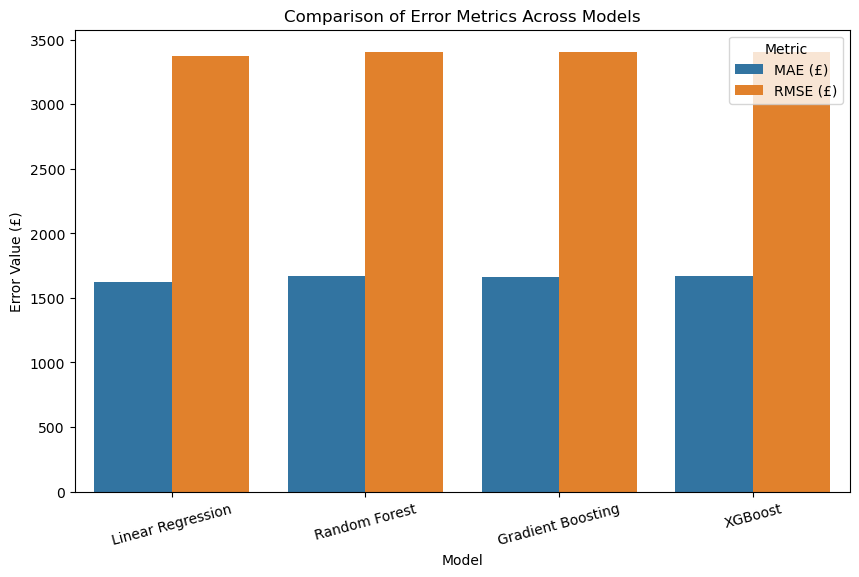

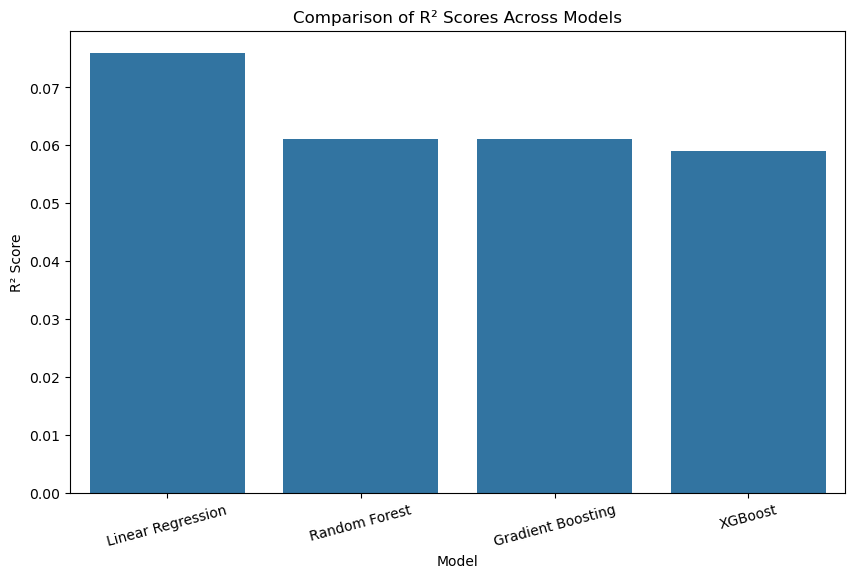

In [41]:
# Create results table
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest',
        'Gradient Boosting',
        'XGBoost'
    ],
    'MAE (£)': [
        lr_mae,
        rf_mae,
        gb_mae,
        xgb_mae
    ],
    'RMSE (£)': [
        lr_rmse,
        rf_rmse,
        gb_rmse,
        xgb_rmse
    ],
    'R2 Score': [
        lr_r2,
        rf_r2,
        gb_r2,
        xgb_r2
    ]
})

# Round results for cleaner presentation
results = results.round(3)

# Display results table
display(results)


# Chart 1: Compare MAE and RMSE
error_metrics = results.melt(
    id_vars='Model',
    value_vars=['MAE (£)', 'RMSE (£)'],
    var_name='Metric',
    value_name='Value'
)

plt.figure(figsize=(10,6))
sns.barplot(data=error_metrics, x='Model', y='Value', hue='Metric')

plt.title("Comparison of Error Metrics Across Models")
plt.xlabel("Model")
plt.ylabel("Error Value (£)")
plt.xticks(rotation=15)
plt.legend(title="Metric")

plt.show()


# Chart 2: Compare R² Score
plt.figure(figsize=(10,6))
sns.barplot(data=results, x='Model', y='R2 Score')

plt.title("Comparison of R² Scores Across Models")
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.xticks(rotation=15)

plt.show()

## Step 10: Feature Importance Analysis

To better understand which factors influence rental price predictions, feature importance analysis is performed using the Random Forest model.

Random Forest provides a measure of feature importance based on how much each feature contributes to reducing prediction error across the decision trees.

By analysing feature importance, it is possible to identify which property characteristics have the greatest influence on rental prices. These may include factors such as property location, number of rooms, and property type.

The results are visualized using a bar chart to highlight the most influential features used by the prediction model.

,Feature,Importance
0,Number of Rooms,0.820742
6,Property_Type_Flat,0.077993
7,Property_Type_House,0.037822
9,Property_Type_Studio,0.021804
5,City_London,0.018916
8,Property_Type_Other,0.018768
2,City_Harrow,0.001442
4,City_Liverpool,0.000933
1,City_Bromley,0.000922
3,City_Leeds,0.000659


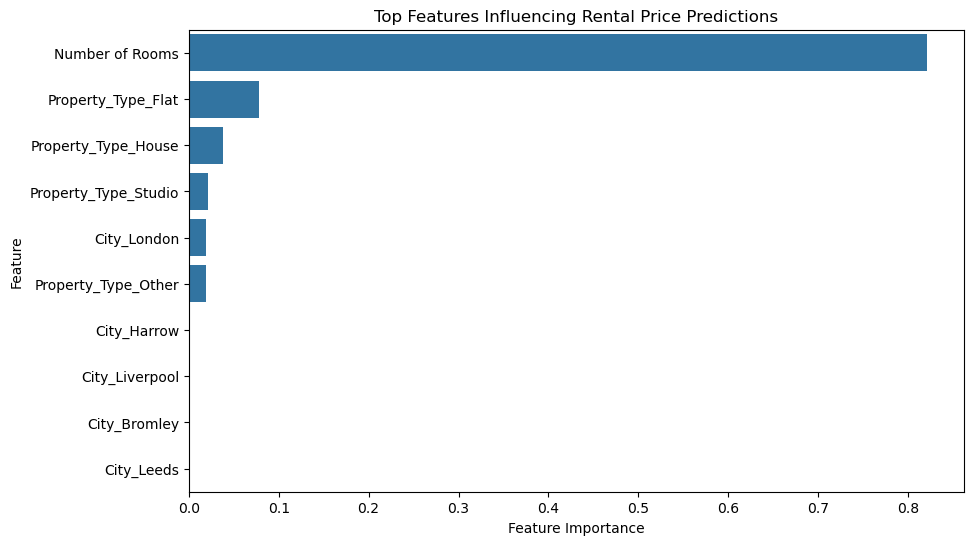

In [42]:
# Get feature importance from Random Forest
feature_importance = rf_model.feature_importances_

# Create dataframe
importance_df = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Importance': feature_importance
})

# Sort features by importance
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Display top features
display(importance_df.head(10))


plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance_df.head(10)
)

plt.title("Top Features Influencing Rental Price Predictions")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.show()

## Step 11: Saving the Best Performing Model

After comparing the performance of the four machine learning models, the best-performing model is selected based on the evaluation metrics.

The selected model is saved along with the preprocessing components used during training. Saving these objects allows the trained model to be reused for predicting rental prices on new data without retraining the entire pipeline.

The following components are saved:

- **Best performing model** used for rental price prediction
- **Scaler** used for feature standardization
- **Feature column structure** used during model training

These components are stored using the Joblib library for efficient model persistence.

In [43]:
# Identify best model based on RMSE (lowest is best)
best_model_name = results.loc[results['RMSE (£)'].idxmin(), 'Model']

print("Best performing model:", best_model_name)

# Select corresponding model object
if best_model_name == "Linear Regression":
    best_model = lr_model
elif best_model_name == "Random Forest":
    best_model = rf_model
elif best_model_name == "Gradient Boosting":
    best_model = gb_model
else:
    best_model = xgb_model

# Save best model
joblib.dump(best_model, "rental_price_model.pkl")

# Save scaler
joblib.dump(scaler, "scaler.pkl")

# Save feature columns
joblib.dump(X_encoded.columns, "rental_model_features.pkl")

print("Best model and preprocessing objects saved successfully.")

Best performing model: Linear Regression
Best model and preprocessing objects saved successfully.


## Step 12: Rental Price Prediction System

After training and saving the selected machine learning model, a prediction function is created to estimate rental prices for new property inputs.

The function loads the saved model and preprocessing components, accepts user input, applies the same preprocessing steps used during training, and generates a rental price prediction.

The prediction system uses the following input features:
- **City**
- **Number of Rooms**
- **Property Type**

Because the model was trained on the **log-transformed rental price**, the predicted output is converted back to the original price scale using the exponential function.

This step demonstrates the practical application of the trained machine learning model as a simple rental price estimation tool.

In [44]:
# Load saved model and preprocessing components
model = joblib.load("rental_price_model.pkl")
scaler = joblib.load("scaler.pkl")
model_features = joblib.load("rental_model_features.pkl")


def predict_rent(city, rooms, property_type):
    # Clean inputs
    city = city.strip().title()
    property_type = property_type.strip().title()

    # Optional mapping if "Apartment" was not used during training
    if property_type == "Apartment":
        property_type = "Flat"

    # Start with all-zero row using the exact training columns
    input_encoded = pd.DataFrame(0, index=[0], columns=model_features)

    # Set numeric feature
    input_encoded.loc[0, "Number of Rooms"] = rooms

    # Set city dummy if it exists in training features
    city_col = f"City_{city}"
    if city_col in input_encoded.columns:
        input_encoded.loc[0, city_col] = 1
    else:
        print(f"Warning: '{city}' was not seen during training. Using baseline city encoding.")

    # Set property type dummy if it exists in training features
    property_col = f"Property_Type_{property_type}"
    if property_col in input_encoded.columns:
        input_encoded.loc[0, property_col] = 1
    else:
        print(f"Warning: '{property_type}' was not seen during training. Using baseline property type encoding.")

    # Scale features
    input_scaled = scaler.transform(input_encoded)

    # Predict log price
    log_prediction = model.predict(input_scaled)

    # Convert back to actual price (£)
    predicted_price = np.exp(log_prediction)

    return predicted_price[0]


# Ask the user for input
city_input = input("Enter the city: ")
rooms_input = int(input("Enter the number of rooms: "))
property_type_input = input("Enter the property type (Flat, House, Studio, Other): ")

# Generate prediction
prediction = predict_rent(city_input, rooms_input, property_type_input)

print(
    f"\nEstimated monthly rent for a {rooms_input}-bedroom "
    f"{property_type_input} in {city_input}: £{prediction:.2f}"
)


Estimated monthly rent for a 1-bedroom Flat in Bromley: £2896.66


c:\Users\oghen\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
